# Chapter 10 tutorial — Part 2: sampling by variables and sample sizes for averages

This notebook covers:

- sampling by variables,
- the zinc-alloy acceptance example,
- operating characteristic curves for variable measurements,
- planning sample sizes for estimating means.

## Mental model

Attribute sampling throws away measurement detail and keeps only pass/fail. Variable sampling keeps the measured value. Keeping more information usually means fewer measurements can achieve the same decision quality.

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binom, hypergeom, norm, chi2
from scipy.optimize import brentq

pd.set_option("display.precision", 4)

## 1. Sampling by variables

In **sampling by variables**, each sampled unit produces a numerical measurement.

Example: a buyer wants zinc alloy with true zinc content at least $42\%$.

A natural plan is:

1. take $N$ measurements,
2. compute the sample mean $\bar X$,
3. accept the lot if

$$
\bar X \ge k.
$$

If individual measurements have known standard deviation $\sigma$, then

$$
\bar X \sim N\left(\mu, \frac{\sigma}{\sqrt N}\right).
$$

Therefore the probability of acceptance at true content $\mu$ is

$$
P_\mu(\text{accept}) = P_\mu(\bar X \ge k)
= 1 - \Phi\left(\frac{k - \mu}{\sigma/\sqrt N}\right).
$$

In [6]:
def p_accept_variables(mu, sigma, N, k):
    return 1 - norm.cdf((k - mu) / (sigma / math.sqrt(N)))

# Example probability for a proposed plan.
p_accept_variables(mu=42.0, sigma=0.45, N=3, k=41.58)

np.float64(0.9470155954363996)

## 2. Deriving the zinc-alloy plan

Suppose we require:

$$
P_{\mu=42}(\text{accept}) = 0.95,
$$

and

$$
P_{\mu=41}(\text{accept}) = 0.01.
$$

Let

$$
z_G = \Phi^{-1}(1 - 0.95), \quad z_B = \Phi^{-1}(1 - 0.01).
$$

Then

$$
\frac{k - 42}{\sigma/\sqrt N} = z_G,
\qquad
\frac{k - 41}{\sigma/\sqrt N} = z_B.
$$

Subtracting the two equations gives

$$
\sqrt N = \frac{(z_B - z_G)\sigma}{42 - 41},
$$

so

$$
N = \left(\frac{(z_B - z_G)\sigma}{42 - 41}\right)^2.
$$

The cutoff is

$$
k = 42 + z_G \frac{42 - 41}{z_B - z_G}.
$$

In [7]:
def solve_variable_sampling_plan(mu_good, accept_good, mu_bad, accept_bad, sigma):
    z_good = norm.ppf(1 - accept_good)
    z_bad = norm.ppf(1 - accept_bad)
    delta = mu_good - mu_bad
    N = ((z_bad - z_good) * sigma / delta) ** 2
    k = mu_good + z_good * delta / (z_bad - z_good)
    return {
        "z_good": z_good,
        "z_bad": z_bad,
        "N_continuous": N,
        "N_floor": math.floor(N),
        "N_ceiling": math.ceil(N),
        "k": k,
    }

plan = solve_variable_sampling_plan(42.0, 0.95, 41.0, 0.01, sigma=0.45)
pd.DataFrame([plan])

,z_good,z_bad,N_continuous,N_floor,N_ceiling,k
0,-1.6449,2.3263,3.1935,3,4,41.5858


The chapter uses rounded normal-table values, giving approximately $k = 41.58$ and $N \approx 3.08$. With exact modern quantiles, the continuous value is close but not identical. Since $N$ must be an integer, you should decide whether the plan is approximate or conservative.

In [8]:
k = 41.58
sigma = 0.45
for N in [3, 4, 5, 6]:
    print(f"N={N}: P_accept(mu=42)={p_accept_variables(42, sigma, N, k):.4f}, "
          f"P_accept(mu=41)={p_accept_variables(41, sigma, N, k):.4f}")

N=3: P_accept(mu=42)=0.9470, P_accept(mu=41)=0.0128
N=4: P_accept(mu=42)=0.9690, P_accept(mu=41)=0.0050
N=5: P_accept(mu=42)=0.9816, P_accept(mu=41)=0.0020
N=6: P_accept(mu=42)=0.9889, P_accept(mu=41)=0.0008


Mental model: $k$ chooses the **decision threshold**, while $N$ chooses how sharply the noisy average concentrates around the true content.

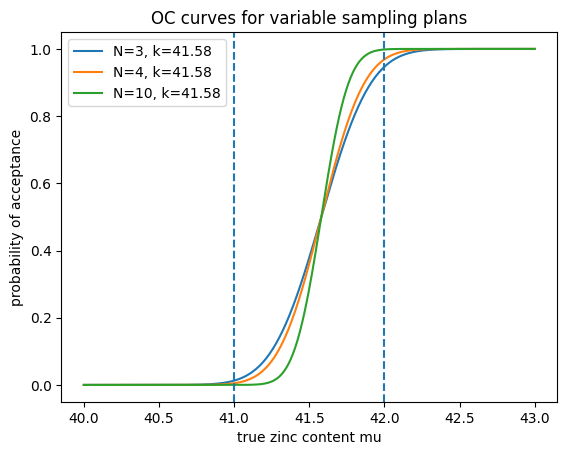

In [9]:
mus = np.linspace(40.0, 43.0, 400)
plt.figure()
for N in [3, 4, 10]:
    plt.plot(mus, [p_accept_variables(mu, sigma=0.45, N=N, k=41.58) for mu in mus], label=f"N={N}, k=41.58")
plt.axvline(41.0, linestyle="--")
plt.axvline(42.0, linestyle="--")
plt.xlabel("true zinc content mu")
plt.ylabel("probability of acceptance")
plt.title("OC curves for variable sampling plans")
plt.legend()
plt.show()

## 3. What if $\sigma$ is unknown?

The elementary derivation above assumes $\sigma$ is known exactly.

Two useful facts remain:

1. The threshold $k$ came from a ratio, so $\sigma$ cancels out.
2. The sample size satisfies

$$
N \propto \sigma^2.
$$

So if $\sigma$ is only approximately known, use a conservative guess. Underestimating $\sigma$ can produce a plan with too little information.

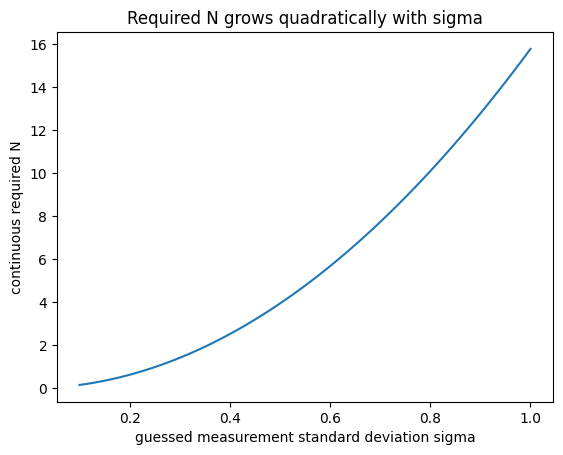

In [10]:
def N_for_sigma_guess(sigma_guess):
    return solve_variable_sampling_plan(42.0, 0.95, 41.0, 0.01, sigma=sigma_guess)["N_continuous"]

sigmas = np.linspace(0.1, 1.0, 100)
plt.figure()
plt.plot(sigmas, [N_for_sigma_guess(s) for s in sigmas])
plt.xlabel("guessed measurement standard deviation sigma")
plt.ylabel("continuous required N")
plt.title("Required N grows quadratically with sigma")
plt.show()

## 4. Objectives and methods of sampling

Before computing a sample size, state the objective.

Common objectives in this chapter:

- accept/reject a lot by attributes,
- accept/reject a lot by variables,
- estimate a population average,
- estimate a population variance or standard deviation,
- compare models or sources of variation.

Mental model: **sample size is not a universal constant**. It is the answer to a specific question with a specific precision target and cost.

## 5. Sample size for estimating an average when $\sigma$ is known

For a random sample of size $N$,

$$
\mathrm{SE}(\bar X) = \frac{\sigma}{\sqrt N}.
$$

If we want

$$
\frac{\sigma}{\sqrt N} < E,
$$

then

$$
N > \frac{\sigma^2}{E^2}.
$$

The square-root law appears again: halving the standard error requires four times as many observations.

In [11]:
def sample_size_mean_known_sigma(sigma, E):
    return math.ceil((sigma / E) ** 2)

pd.DataFrame([
    {"sigma": 0.45, "target SE E": E, "required N": sample_size_mean_known_sigma(0.45, E)}
    for E in [0.20, 0.10, 0.05, 0.025]
])

,sigma,target SE E,required N
0,0.45,0.200,6
1,0.45,0.100,21
2,0.45,0.050,81
3,0.45,0.025,324


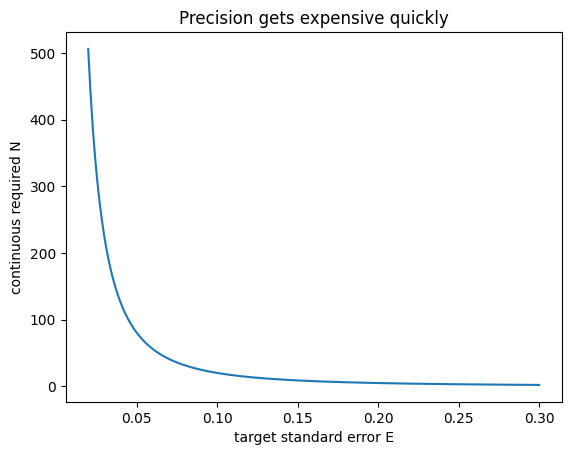

In [12]:
Es = np.linspace(0.02, 0.30, 200)
Ns = [(0.45 / E) ** 2 for E in Es]
plt.figure()
plt.plot(Es, Ns)
plt.xlabel("target standard error E")
plt.ylabel("continuous required N")
plt.title("Precision gets expensive quickly")
plt.show()

## 6. Sample size for estimating an average when $\sigma$ is estimated

If $\sigma$ is not known but an estimate $\hat\sigma$ exists from prior information with $m$ degrees of freedom, the chapter uses the confidence interval length

$$
L = \frac{2t\hat\sigma}{\sqrt N}.
$$

Solving for $N$ gives

$$
N = \frac{4t^2\hat\sigma^2}{L^2}.
$$

Here $t$ is chosen from Student's $t$ table using the degrees of freedom of the prior estimate and the desired confidence coefficient.

In [13]:
def sample_size_mean_unknown_sigma(sigma_hat, L, df_prior, confidence=0.95):
    alpha = 1 - confidence
    t = norm.ppf(1 - alpha/2) if df_prior == math.inf else __import__('scipy').stats.t.ppf(1 - alpha/2, df_prior)
    N_cont = 4 * t**2 * sigma_hat**2 / L**2
    return t, N_cont, math.ceil(N_cont)

t, N_cont, N = sample_size_mean_unknown_sigma(sigma_hat=0.45, L=1.0, df_prior=21, confidence=0.95)
pd.DataFrame([{"t": t, "continuous N": N_cont, "integer N": N}])

,t,continuous N,integer N
0,2.0796,3.5031,4


The worked example asks for zinc content bracketed within $\pm 0.5\%$ zinc with 95% confidence. That means the full interval length is

$$
L = 2(0.5) = 1.0.
$$

With $\hat\sigma = 0.45$ and 21 degrees of freedom, the required sample size rounds up to 4.

In [14]:
# The chapter's four observed zinc measurements.
x = np.array([42.37, 42.18, 42.71, 42.41])
xbar = x.mean()
s_new = x.std(ddof=1)
df_new = len(x) - 1

sigma_prior = 0.45
df_prior = 21
s_pooled = math.sqrt((df_prior * sigma_prior**2 + df_new * s_new**2) / (df_prior + df_new))

t_after = __import__('scipy').stats.t.ppf(0.975, df_prior + df_new)
L_obtained = 2 * t_after * s_pooled / math.sqrt(len(x))

pd.DataFrame([{
    "sample mean": xbar,
    "new sample sd": s_new,
    "new df": df_new,
    "pooled sd": s_pooled,
    "pooled df": df_prior + df_new,
    "actual CI length": L_obtained,
}])

,sample mean,new sample sd,new df,pooled sd,pooled df,actual CI length
0,42.4175,0.2193,3,0.428,24,0.8834


## 7. Cost-aware sampling

The chapter notes that realistic sample-size planning should not ignore sampling and testing cost.

A useful design pattern is to plot the cost of precision before collecting data.

In [15]:
cost_per_measurement = 75  # dollars; change this for your lab or benchmark setting
sigma_hat = 0.45
df_prior = 21
confidence = 0.95

rows = []
for half_width in np.linspace(0.1, 1.0, 10):
    L = 2 * half_width
    _, N_cont, N = sample_size_mean_unknown_sigma(sigma_hat, L, df_prior, confidence)
    rows.append({"desired half-width": half_width, "N": N, "estimated cost": N * cost_per_measurement})

cost_table = pd.DataFrame(rows)
cost_table

,desired half-width,N,estimated cost
0,0.1,88,6600
1,0.2,22,1650
2,0.3,10,750
3,0.4,6,450
4,0.5,4,300
5,0.6,3,225
6,0.7,2,150
7,0.8,2,150
8,0.9,2,150
9,1.0,1,75


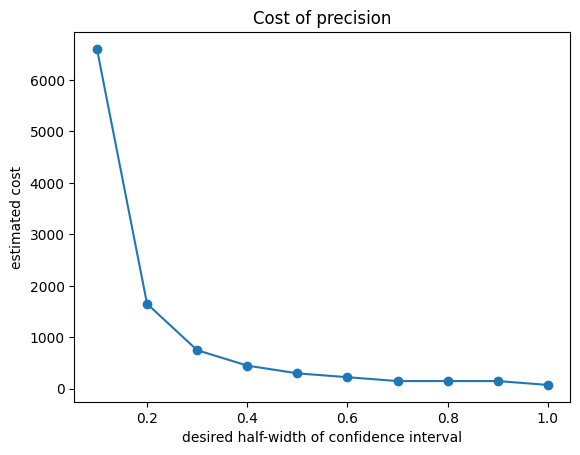

In [16]:
plt.figure()
plt.plot(cost_table["desired half-width"], cost_table["estimated cost"], marker="o")
plt.xlabel("desired half-width of confidence interval")
plt.ylabel("estimated cost")
plt.title("Cost of precision")
plt.show()

## 8. Applied translation: benchmark measurements

For benchmark data analysis, replace “zinc content” by “throughput,” “latency,” or “IOPS.”

The same design questions apply:

- Are you making an accept/reject decision?
- Are you estimating a mean?
- What interval length is useful enough to act on?
- What prior estimate of run-to-run standard deviation is available?
- What does one additional benchmark run cost?

Mental model: a benchmark run is a measurement process. Sampling theory is the planning layer that decides how many runs make the result usable.